In [1]:
import pandas as pd
dataset=pd.read_csv("SBIN_data.csv", parse_dates=['Date'], index_col='Date')
dataset


,Close,High,Low,Open,Volume
Date,,,,,
2024-01-01,618.355835,623.706899,615.125965,619.175395,8295548
2024-01-02,616.523987,624.767434,611.124727,618.355831,15164482
2024-01-03,620.380554,624.767412,613.004804,616.427515,14571772
2024-01-04,619.705627,623.224788,615.752647,619.464591,13883388
2024-01-05,618.934387,628.383019,614.884957,621.875025,15984585
...,...,...,...,...,...
2024-12-24,796.065369,809.936860,793.271493,808.025232,10602771
2024-12-26,796.457520,806.652767,792.095103,796.996681,8318714
2024-12-27,783.909485,802.192337,781.507699,800.231706,10649800


In [ ]:
# Resampled to Business Days - Monday to Friday
dummy_dataset = dataset.resample('B').ffill()
dummy_dataset


,Close,High,Low,Open,Volume
Date,,,,,
2024-01-01,618.355835,623.706899,615.125965,619.175395,8295548
2024-01-02,616.523987,624.767434,611.124727,618.355831,15164482
2024-01-03,620.380554,624.767412,613.004804,616.427515,14571772
2024-01-04,619.705627,623.224788,615.752647,619.464591,13883388
2024-01-05,618.934387,628.383019,614.884957,621.875025,15984585
...,...,...,...,...,...
2024-12-25,796.065369,809.936860,793.271493,808.025232,10602771
2024-12-26,796.457520,806.652767,792.095103,796.996681,8318714
2024-12-27,783.909485,802.192337,781.507699,800.231706,10649800


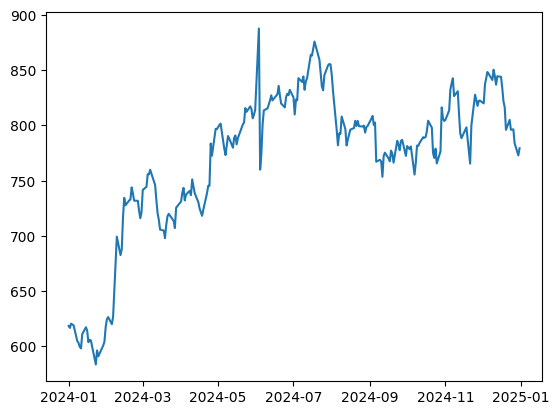

In [7]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.plot(dataset["Close"])
plt.show()


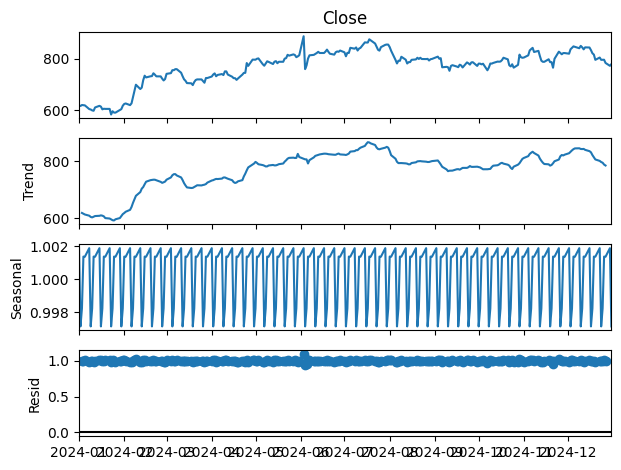

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(dummy_dataset["Close"], model='multiplicative')
result.plot()
plt.show()


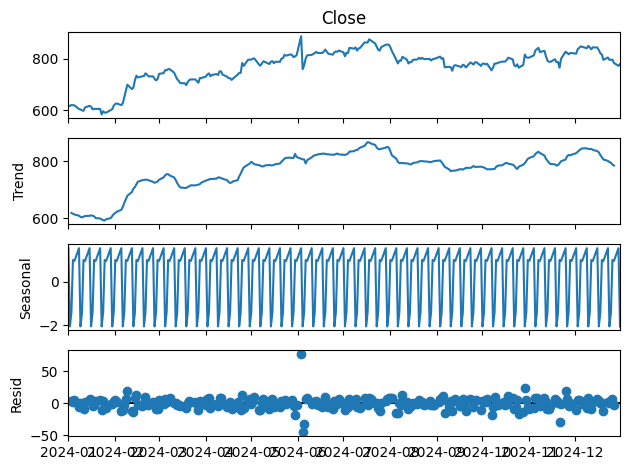

In [15]:

result = seasonal_decompose(dummy_dataset["Close"], model='additive')
result.plot()
plt.show()


In [44]:
from statsmodels.tsa.stattools import adfuller

def adf_test(timeseries, col_name):
    print("Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis")
    print("Reject null hypothesis: Non Stationary")
    print("Accept Alternate hypothesis: Staionary ")  

    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags','Observations'])
    for key,value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    
    print("\nADF Results:", dfoutput, sep="\n")

    test_stat = dfoutput['Test Statistic']
    p_val = dfoutput['p-value']
    crit_values = [dfoutput[f'Critical Value ({level})'] for level in ['1%', '5%', '10%']]
    
    stat_condition = test_stat < min(crit_values)
    p_condition = p_val < 0.05
    
    if stat_condition and p_condition:
        conclusion = "Stationary"
    else:
        conclusion = "Non-Stationary"
    
    print(f"\n{conclusion}: stat<{min(crit_values):.3f} and p={p_val:.4f}<0.05")
    
    # Plot
    plt.figure(figsize=(15,6))
    plt.plot(timeseries.index, timeseries, label=col_name)
    plt.title(f'{col_name}: ADF {conclusion} (p={p_val:.3f})')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{col_name}_ADF.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return conclusion


Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis
Reject null hypothesis: Non Stationary
Accept Alternate hypothesis: Staionary 

ADF Results:
Test Statistic           -2.374781
p-value                   0.148981
#Lags                     1.000000
Observations            244.000000
Critical Value (1%)      -3.457438
Critical Value (5%)      -2.873459
Critical Value (10%)     -2.573122
dtype: float64

Non-Stationary: stat<-3.457 and p=0.1490<0.05


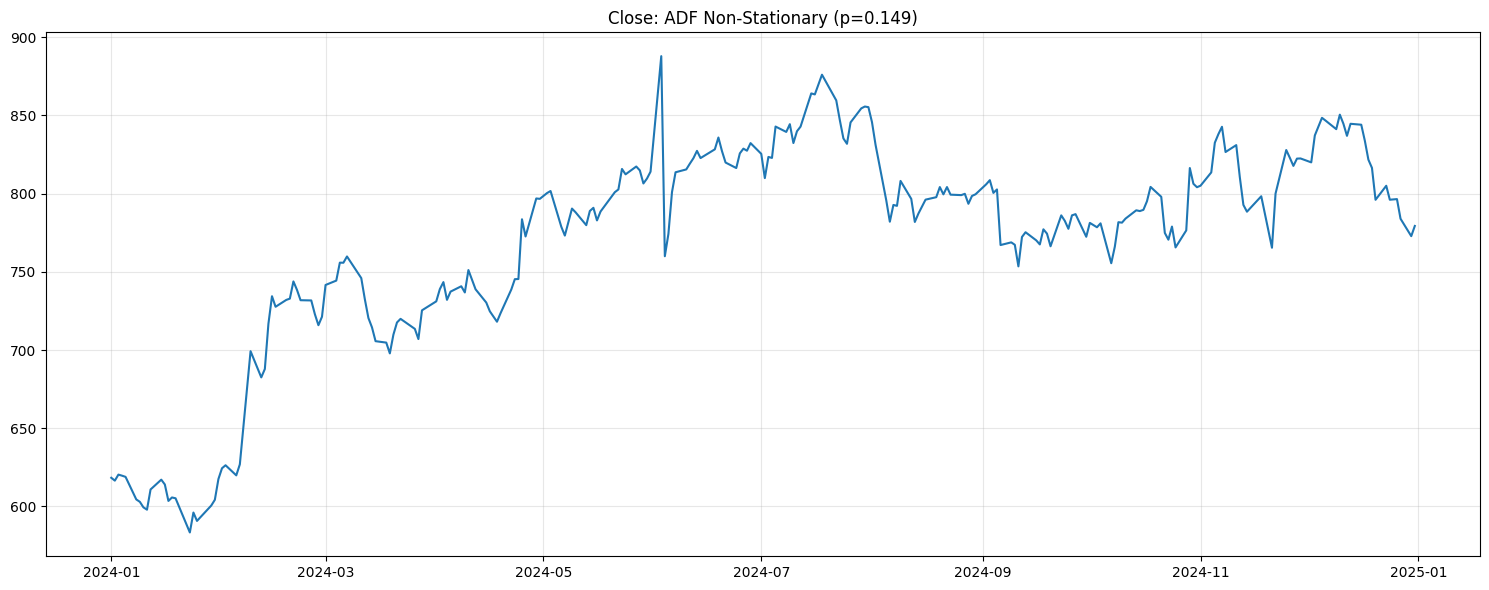

'Non-Stationary'

In [45]:
adf_test(dataset["Close"],"Close")


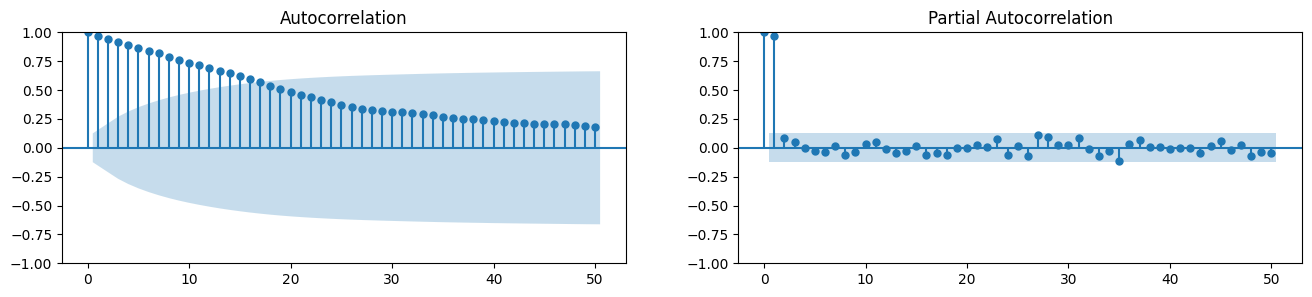

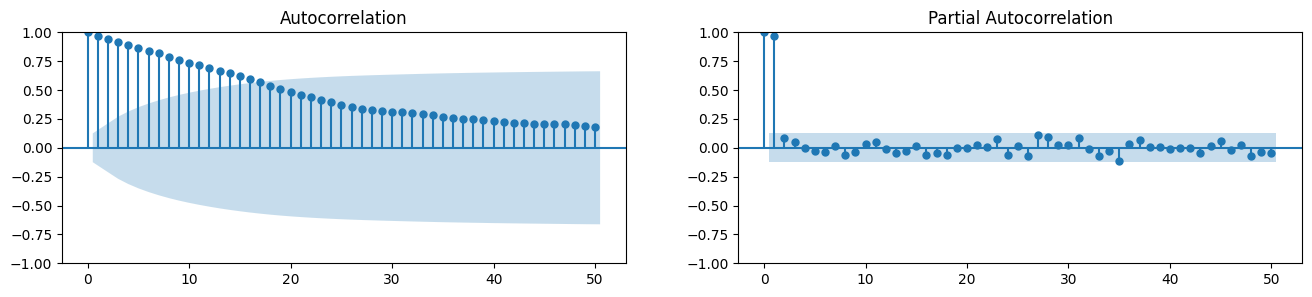

In [46]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(dataset.Close.tolist(), lags=50, ax=axes[0])
plot_pacf(dataset.Close.tolist(), lags=50, ax=axes[1])


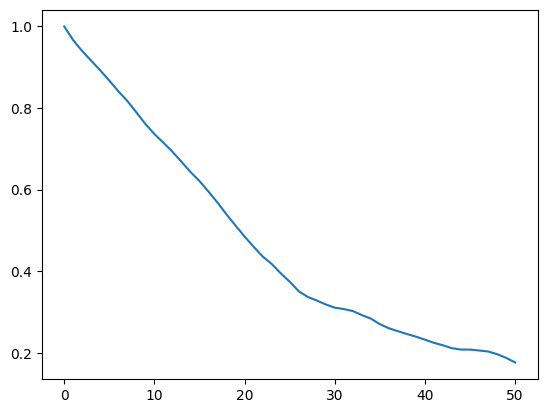

In [47]:
plt.plot(acf(dataset["Close"],nlags=50))
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

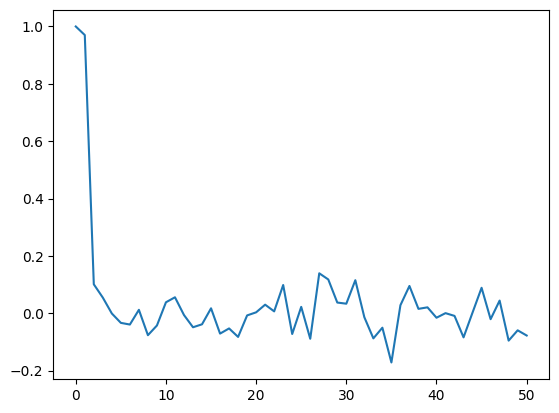

In [48]:
plt.plot(pacf(dataset["Close"],nlags=50))
plt.show


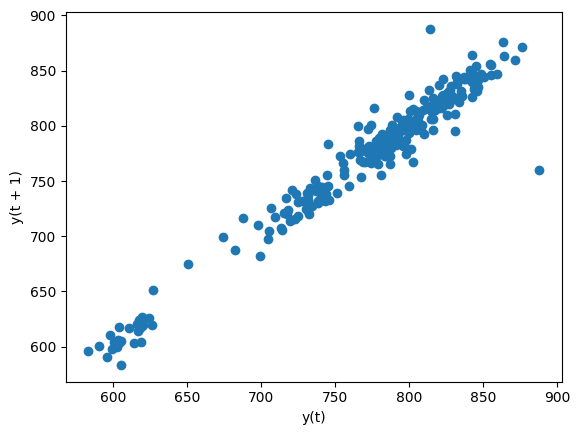

In [ ]:
# Scatter plot of Close(t) vs Close(t-1) to detect autocorrelation patterns 
from pandas.plotting import lag_plot
lag_plot(dataset["Close"],lag=1)
plt.show()


## Forecastability

### Apen small- Forecastability is possible
### Spen Small-Forecastability is possible

In [ ]:
# Measures how "random" or "predictable" the patterns are, by comparing similarity of data blocks of length m within tolerance r.
import numpy as np
# Compute Aproximate entropy

def ApEn(U, m, r):
    # U = Input time series - the raw data
    # m = Embedding dimension (pattern length) - typically 2 or 3
    # r = Tolerance threshold (similarity criterion) - 0.1-0.25 × std(U)
    
    # Distance between two data blocks (max absolute difference)
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    # Counts how many similar blocks of length m exist, takes log-probability
    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for x_j in x if _maxdist(x_i, x_j) <= r]) / (N - m + 1.0) for x_i in x]
        return (N - m + 1.0)**(-1) * sum(np.log(C))

    N = len(U)
    # ApEn = |phi(m+1) - phi(m)|: Difference tells irregularity - higher = more random, lower = more regular/predictable
    return abs(_phi(m+1) - _phi(m))



In [56]:
import numpy as np
U=dataset["Close"].values
r = 0.2 * np.std(U)
ApEn_value = ApEn(U, m=2, r=r)

if ApEn_value < 0.7:
    print(f"ApEn: {ApEn_value:.3f} is < 0.7. \nForecastability is Possible")
else:
    print(f"ApEn: {ApEn_value:.3f} is > 0.7\nForecastability is not Possible")


ApEn: 0.575 is < 0.7. 
Forecastability is Possible


In [54]:
# Compute Sample entropy
def SampEn(U, m, r):

    # max distance between data blocks
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    # Counts similar pairs EXCLUDING itself (ApEn included self)
    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for j in range(len(x)) if i != j and _maxdist(x[i], x[j]) <= r]) for i in range(len(x))]
        return sum(C)

    N = len(U)
    # Ratio of similarities - higher = more random
    return -np.log(_phi(m+1) / _phi(m))


In [57]:
U=dataset["Close"].values
r = 0.2 * np.std(U)
SampEn_value = SampEn(U, m=2, r=r)

if SampEn_value < 0.7:
    print(f"SampEn: {SampEn_value:.3f} is < 0.7. \nForecastability is Possible")
else:
    print(f"SampEn: {SampEn_value:.3f} is > 0.7\nForecastability is not Possible")


SampEn: 0.533 is < 0.7. 
Forecastability is Possible
